In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler, RobustScaler #Para normalizar o estandarizar
from sklearn.pipeline import Pipeline #PIPELINE -> SERIE DE INSTRUCCIONES PARA TRANSFORMAR DATOS

In [ ]:
df = pd.read_csv("Phishing.csv")
df

,Querylength,domain_token_count,path_token_count,avgdomaintokenlen,longdomaintokenlen,avgpathtokenlen,tld,charcompvowels,charcompace,ldl_url,...,SymbolCount_FileName,SymbolCount_Extension,SymbolCount_Afterpath,Entropy_URL,Entropy_Domain,Entropy_DirectoryName,Entropy_Filename,Entropy_Extension,Entropy_Afterpath,URL_Type_obf_Type
0,0,2,12,5.500000,8,4.083334,2,15,7,0,...,-1,-1,-1,0.676804,0.860529,-1.000000,-1.000000,-1.00000,-1.000000,benign
1,0,3,12,5.000000,10,3.583333,3,12,8,2,...,1,0,-1,0.715629,0.776796,0.693127,0.738315,1.00000,-1.000000,benign
2,2,2,11,4.000000,5,4.750000,2,16,11,0,...,2,0,1,0.677701,1.000000,0.677704,0.916667,0.00000,0.898227,benign
3,0,2,7,4.500000,7,5.714286,2,15,10,0,...,0,0,-1,0.696067,0.879588,0.818007,0.753585,0.00000,-1.000000,benign
4,19,2,10,6.000000,9,2.250000,2,9,5,0,...,5,4,3,0.747202,0.833700,0.655459,0.829535,0.83615,0.823008,benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15362,0,2,3,8.000000,13,3.333333,2,3,2,0,...,0,0,-1,0.797046,0.884870,0.750000,1.000000,0.00000,-1.000000,phishing
15363,0,3,0,9.000000,16,NaN,3,0,0,0,...,-1,-1,-1,0.797564,0.813569,-1.000000,-1.000000,-1.00000,-1.000000,phishing
15364,0,3,2,6.666666,10,3.000000,3,3,2,0,...,0,0,-1,0.791104,0.801139,NaN,1.000000,0.00000,-1.000000,phishing
15365,0,2,3,8.000000,13,3.333333,2,4,2,0,...,0,0,-1,0.716580,0.787659,0.871049,1.000000,0.00000,-1.000000,phishing


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15367 entries, 0 to 15366
Data columns (total 80 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Querylength                      15367 non-null  int64  
 1   domain_token_count               15367 non-null  int64  
 2   path_token_count                 15367 non-null  int64  
 3   avgdomaintokenlen                15367 non-null  float64
 4   longdomaintokenlen               15367 non-null  int64  
 5   avgpathtokenlen                  15096 non-null  float64
 6   tld                              15367 non-null  int64  
 7   charcompvowels                   15367 non-null  int64  
 8   charcompace                      15367 non-null  int64  
 9   ldl_url                          15367 non-null  int64  
 10  ldl_domain                       15367 non-null  int64  
 11  ldl_path                         15367 non-null  int64  
 12  ldl_filename      

In [ ]:
df['URL_Type_obf_Type'].value_counts()

,count
URL_Type_obf_Type,
benign,7781
phishing,7586


In [ ]:
is_null = df.isna().any() #ISNA -> VER SI NO ES NUM OSEA VALOR FALTANTE.
is_null[is_null]

,0
avgpathtokenlen,True
NumberRate_DirectoryName,True
NumberRate_FileName,True
NumberRate_Extension,True
NumberRate_AfterPath,True
Entropy_DirectoryName,True
Entropy_Filename,True
Entropy_Extension,True
Entropy_Afterpath,True


In [ ]:
# Comprobación de la existencia de valores infinitos
is_inf = df.isin([np.inf, -np.inf]).any()
is_inf[is_inf]

,0
argPathRatio,True


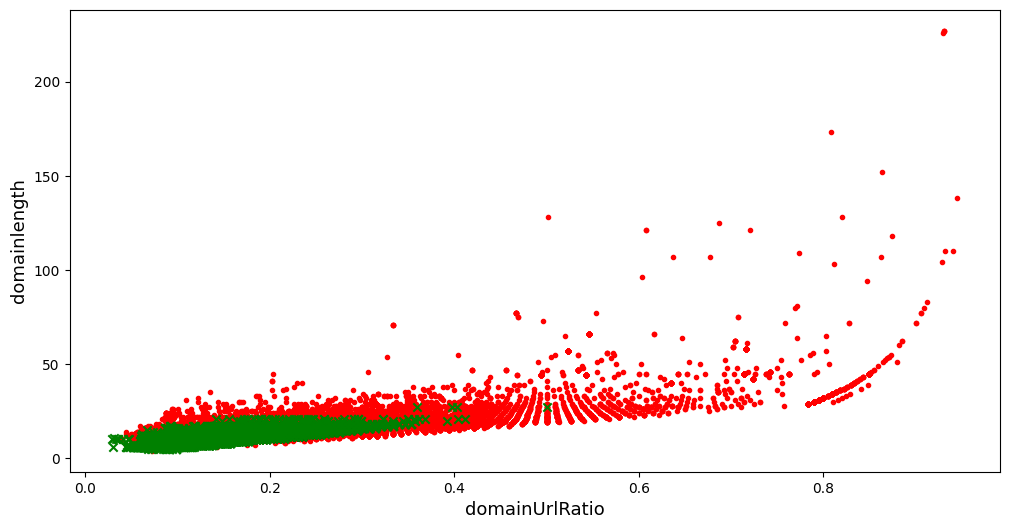

In [ ]:
# Representación para dos variables
# domainUrlRatio Y domainlength
plt.figure(figsize=(12, 6))
plt.scatter(df['domainUrlRatio'][df['URL_Type_obf_Type'] == 'phishing'], df['domainlength'][df['URL_Type_obf_Type'] == 'phishing'], c="r", marker=".")
plt.scatter(df['domainUrlRatio'][df['URL_Type_obf_Type'] == 'benign'], df['domainlength'][df['URL_Type_obf_Type'] == 'benign'], c="g", marker="x")
plt.xlabel("domainUrlRatio", fontsize=13)
plt.ylabel("domainlength", fontsize=13)
plt.show()

In [ ]:

X = df.drop(['URL_Type_obf_Type'], axis=1)
y = df['URL_Type_obf_Type']
y = y.map({'benign': 0, 'phishing': 1})
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42,stratify=y) #DIVIDE EN CONJUNTO DE ENTRENAMIENTO Y PRUEBA ||| stratify usado para dividir cuando hay pocos valores

In [ ]:
# Eliminamos la variable que tiene valores infinitos

X_train = X_train.drop(['argPathRatio'], axis=1)
X_test = X_test.drop(['argPathRatio'], axis=1)

# Rellenamos los valores nulos con la mediana

from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")

#X_train = imputer.fit_transform(X_train)
#X_test = imputer.fit_transform(X_test)

In [ ]:
# Checar si existen valores nulos o infinitos

In [ ]:
# Vamos a usar sólo dos variables

X_train_2 = X_train[['domainUrlRatio', 'domainlength']]
X_test_2 = X_test[['domainUrlRatio', 'domainlength']]

In [ ]:
 #Muy parecido a la regresión logisitica
 from sklearn.svm import SVC

# SVM Large Margin Classification
svm_clf = SVC(kernel="linear", C=1)   #C=1 es el hiperparámetro, pertenece al SVM
svm_clf.fit(X_train_2, y_train)

SVC(C=1, kernel='linear')

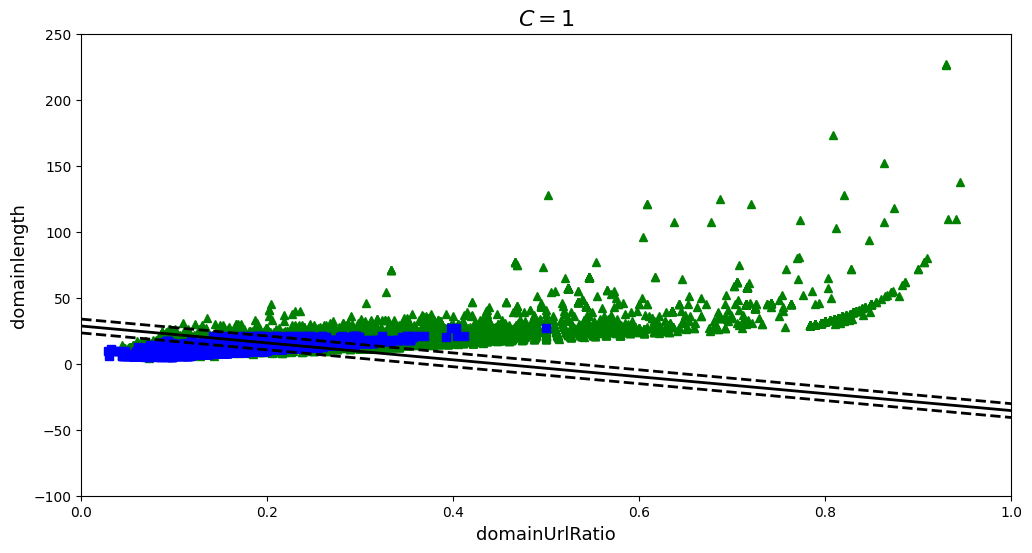

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(X_train_2.values[:, 0][y_train==1], X_train_2.values[:, 1][y_train==1], "g^")
plt.plot(X_train_2.values[:, 0][y_train==0], X_train_2.values[:, 1][y_train==0], "bs")

w = svm_clf.coef_[0]    #m -> pendiente
b = svm_clf.intercept_[0]  #b
x0 = np.linspace(0, 1, 200)
decision_boundary = -w[0]/w[1] * x0 - b/w[1]
margin = 1/w[1]
gutter_up = decision_boundary + margin
gutter_down = decision_boundary - margin
svs = svm_clf.support_vectors_
#plt.scatter(svs[:, 0], svs[:, 1], s=180, facecolors='#FFAAAA')
plt.plot(x0, decision_boundary, "k-", linewidth=2)
plt.plot(x0, gutter_up, "k--", linewidth=2)
plt.plot(x0, gutter_down, "k--", linewidth=2)

plt.title("$C = {}$".format(svm_clf.C), fontsize=16)
plt.axis([0, 1, -100, 250])
plt.xlabel("domainUrlRatio", fontsize=13)
plt.ylabel("domainlength", fontsize=13)
plt.show()



In [ ]:
#Qué tan bueno es el modelo
y_pred = svm_clf.predict(X_test_2)
f1_score(y_test, y_pred)

0.8319355920831936

In [ ]:

from sklearn import metrics
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
cnf_matrix

array([[1474,   83],
       [ 271, 1246]])

Text(0.5, 427.9555555555555, 'Valor predicho')

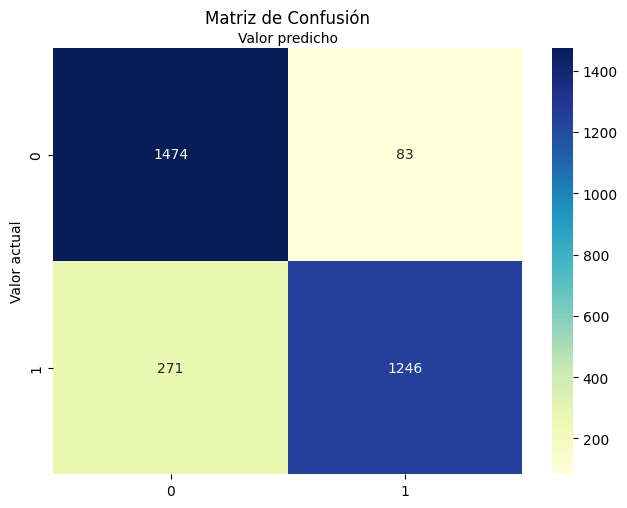

In [ ]:
#Matriz de confusión
import seaborn as sns
fig, ax = plt.subplots()
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu",fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Matriz de Confusión')
plt.ylabel('Valor actual')
plt.xlabel('Valor predicho')

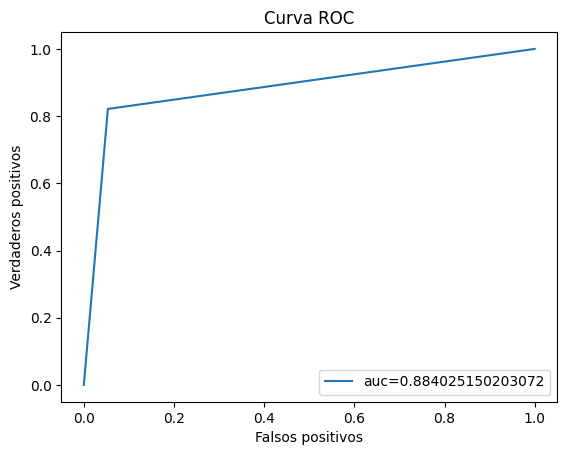

In [ ]:
#Curva ROC (Característica Operativa del Receptor)
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred)
auc = metrics.roc_auc_score(y_test, y_pred)
plt.plot(fpr,tpr,label="auc="+str(auc))
plt.legend(loc=4)
plt.xlabel('Falsos positivos')
plt.ylabel('Verdaderos positivos')
plt.title('Curva ROC')
plt.show()

Kernel Gaussiano

In [ ]:
from sklearn.svm import SVC

# SVM Kernel Gaussiano
svm_clf = SVC(kernel="rbf",gamma=0.5, C=1000)  #C -> PANLIZA GAMMA -> CUANTO ELEVA LA CAMPANA
svm_clf.fit(X_train_2, y_train)

SVC(C=1000, gamma=0.5)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


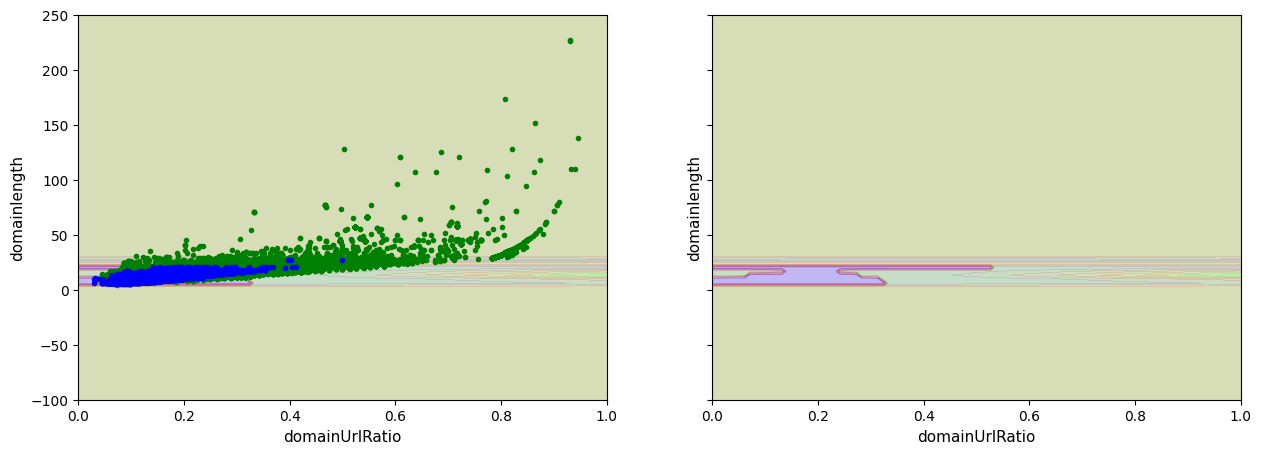

In [ ]:
def plot_dataset(X, y):
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], "g.")
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], "b.")

def plot_predictions(clf, axes):
    x0s = np.linspace(axes[0], axes[1], 100)
    x1s = np.linspace(axes[2], axes[3], 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    X = np.c_[x0.ravel(), x1.ravel()]
    y_pred = clf.predict(X).reshape(x0.shape)
    y_decision = clf.decision_function(X).reshape(x0.shape)
    plt.contourf(x0, x1, y_pred, cmap=plt.cm.brg, alpha=0.2)
    plt.contourf(x0, x1, y_decision, cmap=plt.cm.brg, alpha=0.1)

fig, axes = plt.subplots(ncols=2, figsize=(15,5), sharey=True)
plt.sca(axes[0])
plot_dataset(X_train_2.values, y_train)
plot_predictions(svm_clf, [0, 1, -100, 250])
plt.xlabel("domainUrlRatio", fontsize=11)
plt.ylabel("domainlength", fontsize=11)
plt.sca(axes[1])
plot_predictions(svm_clf, [0, 1, -100, 250])
plt.xlabel("domainUrlRatio", fontsize=11)
plt.ylabel("domainlength", fontsize=11)
plt.show()

In [ ]:
y_pred = svm_clf.predict(X_test_2)
f1_score(y_test, y_pred)  #RESULTADO DEL MÉTODO MEJORÓ DE 0.83 A 0.87

0.8756148981026002

In [ ]:
from sklearn import metrics
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
cnf_matrix

array([[1474,   83],
       [ 271, 1246]])

Text(0.5, 427.9555555555555, 'Valor predicho')

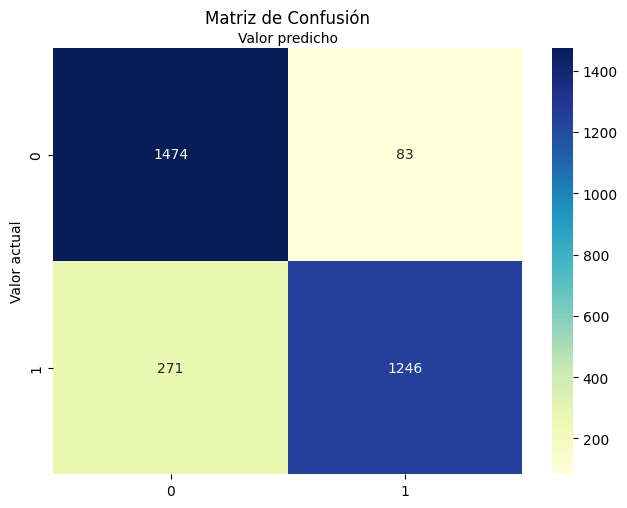

In [ ]:
import seaborn as sns
fig, ax = plt.subplots()
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu",fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Matriz de Confusión')
plt.ylabel('Valor actual')
plt.xlabel('Valor predicho')

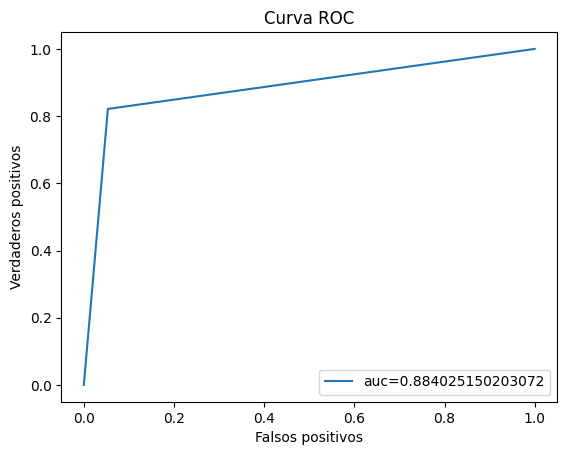

In [ ]:
#Curva ROC (Característica Operativa del Receptor)
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred)
auc = metrics.roc_auc_score(y_test, y_pred)
plt.plot(fpr,tpr,label="auc="+str(auc))
plt.legend(loc=4)
plt.xlabel('Falsos positivos')
plt.ylabel('Verdaderos positivos')
plt.title('Curva ROC')
plt.show()